<a href="https://colab.research.google.com/github/Ziayan1/Synoptic-Project/blob/master/Advanced_ML_AutoTrader_Ziayan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#6G7V0017 Advanced Machine Learning
Machine Learning Project - AutoTrader Vehicle Price Prediction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#basic libraries
import pandas as pd
import numpy as np
#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing and modelling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

#Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, r2_score

#Feature selection
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import SelectFromModel

#Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

#Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor


)
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay





In [ ]:
#loading file from dataset
file_path = "/content/drive/MyDrive/Advanced_ML_Assignment/adverts.csv"
df = pd.read_csv(file_path)
df.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [ ]:
df.shape

(402005, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


In [ ]:
df.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
public_reference,402005.0,NaN,NaN,NaN,202007077472444.46875,16916615997.343893,201307177852187.0,202009023197699.0,202009304400624.0,202010175124399.0,202011025683478.0
mileage,401878.0,NaN,NaN,NaN,37743.595656,34831.724018,0.0,10481.0,28629.5,56875.75,999999.0
reg_code,370148,72,17,36738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_colour,396627,22,Black,86287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_make,402005,110,BMW,37376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_model,402005,1168,Golf,11583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_condition,402005,2,USED,370756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year_of_registration,368694.0,NaN,NaN,NaN,2015.006206,7.962667,999.0,2013.0,2016.0,2018.0,2020.0
price,402005.0,NaN,NaN,NaN,17341.965799,46437.460951,120.0,7495.0,12600.0,20000.0,9999999.0
body_type,401168,16,Hatchback,167315,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#checking for missing values
missing_values = df.isnull().sum().sort_values(ascending =False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percent": missing_percent
    })
missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Missing Percent
year_of_registration,33311,8.286215
reg_code,31857,7.924528
standard_colour,5378,1.337794
body_type,837,0.208206
fuel_type,601,0.149501
mileage,127,0.031592


In [ ]:
df["price"].describe()

,price
count,4.020050e+05
mean,1.734197e+04
std,4.643746e+04
min,1.200000e+02
25%,7.495000e+03
50%,1.260000e+04
75%,2.000000e+04
max,9.999999e+06


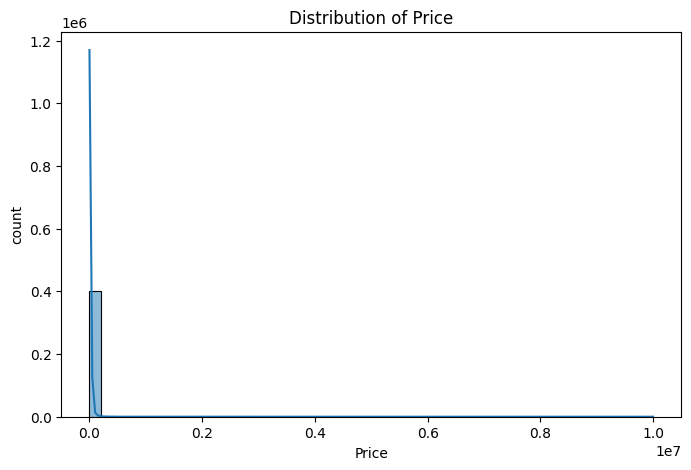

In [ ]:
plt.figure(figsize =(8, 5))
sns.histplot(df["price"], bins = 50, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("count")
plt.show()

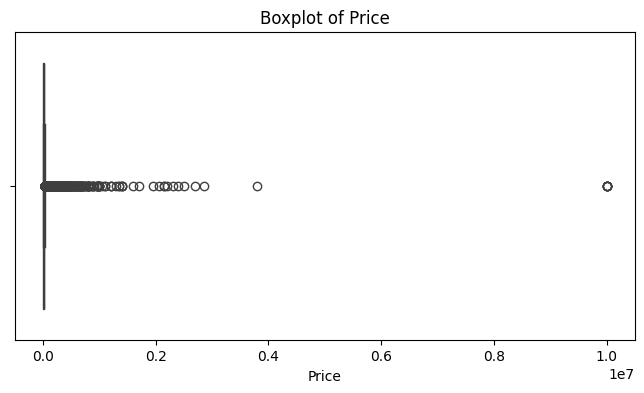

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.show()


In [ ]:
#capping features
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(df[column] < lower_limit, lower_limit, df[column])
    data[column] = np.where(df[column] > upper_limit, upper_limit, df[column])

    return data

In [ ]:
df.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [ ]:
df.shape

(402005, 12)

In [ ]:
df.columns

Index(['public_reference', 'mileage', 'reg_code', 'standard_colour',
       'standard_make', 'standard_model', 'vehicle_condition',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type'],
      dtype='object')

In [ ]:
df.isnull().sum().sort_values(ascending =False).head(20)

,0
year_of_registration,33311
reg_code,31857
standard_colour,5378
body_type,837
fuel_type,601
mileage,127
public_reference,0
standard_make,0
vehicle_condition,0
standard_model,0


In [ ]:
df["price"].describe()

,price
count,4.020050e+05
mean,1.734197e+04
std,4.643746e+04
min,1.200000e+02
25%,7.495000e+03
50%,1.260000e+04
75%,2.000000e+04
max,9.999999e+06


#Preprocessing

In [ ]:
#making a clean copy
df_clean = df.copy()
print("Original shape;", df_clean.shape)

Original shape; (402005, 12)


In [ ]:
#dropping missing values from rows missing
df_clean = df_clean.dropna(axis=0)
print("Shape after dropping missing values;", df_clean.shape)
print("Rows removed due due to missing values:", df.shape[0] - df_clean.shape[0])


Shape after dropping missing values; (363424, 12)
Rows removed due due to missing values: 38581


In [ ]:
#removing public reference column
df_clean["public_reference"].head()

,public_reference
1,202007020778260
2,202007020778474
3,202007080986776
4,202007161321269
5,202009304412074


In [ ]:
#checking for duplicates
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean[df_clean.duplicated()].head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


In [ ]:
#fixing the price outlier
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data, lower_limit, upper_limit

In [ ]:
#Applying it to the price
df_clean, price_lower, price_upper = cap_outliers_iqr(df_clean, "price")

print("Lower limit:", price_lower)
print("Upper limit:", price_upper)

df_clean["price"].describe()



Lower limit: -10245.0
Upper limit: 35739.0


,price
count,363424.000000
mean,13857.982995
std,9124.542760
min,120.000000
25%,6999.000000
50%,11800.000000
75%,18495.000000
max,35739.000000


In [ ]:
df_clean["mileage"].describe()

,mileage
count,363424.000000
mean,40941.547259
std,34326.610856
min,0.000000
25%,14568.000000
50%,31925.000000
75%,60000.000000
max,999999.000000


In [ ]:
#fixing mileage outliers by capping
df_clean, mileage_lower, mileage_upper = cap_outliers_iqr(df_clean, "mileage")

print("Lower limit:", mileage_lower)
print("Upper limit:", mileage_upper)

df_clean["mileage"].describe()

Lower limit: -53580.0
Upper limit: 128148.0


,mileage
count,363424.000000
mean,40462.421720
std,32573.160736
min,0.000000
25%,14568.000000
50%,31925.000000
75%,60000.000000
max,128148.000000


In [ ]:
# in case the mileage lower cap becomes negative
df_clean["mileage"] = np.where(df_clean["mileage"] < 0, 0, df_clean["mileage"])


In [ ]:
# 7. Feature engineering

# 2020 is used as the reference year
reference_year = 2020

# Vehicle age help predict price
df_clean["vehicle_age"] = reference_year - df_clean["year_of_registration"]

# Vehicle age cannot be negative
df_clean["vehicle_age"] = np.where(df_clean["vehicle_age"] < 0, 0, df_clean["vehicle_age"])

#Unrealistic ages are capped instead of deleting rows
df_clean, age_lower, age_upper = cap_outliers_iqr(df_clean, "vehicle_age")

# Vehicle age cannot be negative
df_clean["vehicle_age"] = np.where(df_clean["vehicle_age"] < 0, 0, df_clean["vehicle_age"])

print("Vehicle age lower cap:", age_lower)
print("Vehicle age upper cap:", age_upper)

# Mileage per year shows how car has been used each year
df_clean["mileage_per_year"] = df_clean["mileage"] / (df_clean["vehicle_age"] + 1)

df_clean[["year_of_registration", "vehicle_age", "mileage", "mileage_per_year"]].head()

Vehicle age lower cap: -5.5
Vehicle age upper cap: 14.5


,year_of_registration,vehicle_age,mileage,mileage_per_year
1,2011.0,9.0,108230.0,10823.000000
2,2017.0,3.0,7800.0,1950.000000
3,2016.0,4.0,45000.0,9000.000000
4,2015.0,5.0,64000.0,10666.666667
5,2017.0,3.0,16000.0,4000.000000


In [ ]:
# 8. Cap mileage per year outliers

# The engineered feature may contain extreme values
df_clean, mpy_lower, mpy_upper = cap_outliers_iqr(df_clean, "mileage_per_year")

# Mileage per year cannot be negative
df_clean["mileage_per_year"] = np.where(df_clean["mileage_per_year"] < 0, 0, df_clean["mileage_per_year"])

print("Mileage per year lower cap:", mpy_lower)
print("Mileage per year upper cap:", mpy_upper)

df_clean["mileage_per_year"].describe()

Mileage per year lower cap: -2740.0741792929302
Mileage per year upper cap: 15316.771780303032


,mileage_per_year
count,363424.000000
mean,6527.189833
std,3510.042883
min,0.000000
25%,4031.243056
50%,6166.666667
75%,8545.454545
max,15316.771780


In [ ]:
df_clean["mileage_per_year"] = np.where(df_clean["mileage_per_year"] < 0, 0, df_clean["mileage_per_year"])

In [ ]:
print("Final cleaned shape:", df_clean.shape)

df_clean.isnull().sum()

Final cleaned shape: (363424, 14)


,0
public_reference,0
mileage,0
reg_code,0
standard_colour,0
standard_make,0
standard_model,0
vehicle_condition,0
year_of_registration,0
price,0
body_type,0


In [ ]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
public_reference,363424.0,NaN,NaN,NaN,202007351748256.6875,16374766392.859711,201307177852187.0,202009033286315.25,202010014429167.5,202010185149956.75,202011025683478.0
mileage,363424.0,NaN,NaN,NaN,40462.42172,32573.160736,0.0,14568.0,31925.0,60000.0,128148.0
reg_code,363424,64,17,36298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_colour,363424,22,Black,79971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_make,363424,103,BMW,35277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_model,363424,1091,Golf,10748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_condition,363424,1,USED,363424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year_of_registration,363424.0,NaN,NaN,NaN,2015.038165,7.939168,999.0,2013.0,2016.0,2018.0,2020.0
price,363424.0,NaN,NaN,NaN,13857.982995,9124.54276,120.0,6999.0,11800.0,18495.0,35739.0
body_type,363424,16,Hatchback,154384,NaN,NaN,NaN,NaN,NaN,NaN,NaN


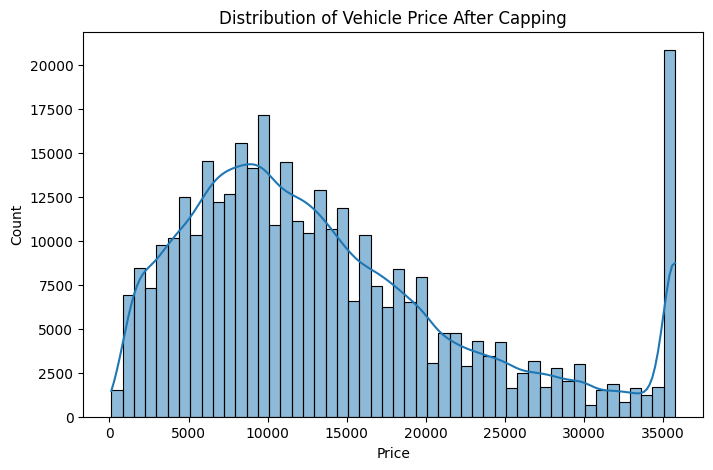

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribution of Vehicle Price After Capping")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

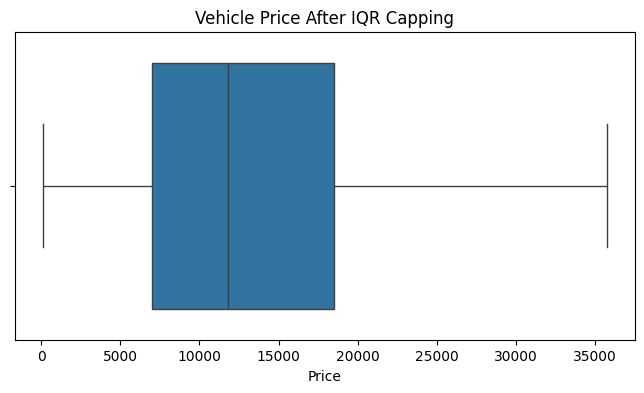

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["price"])
plt.title("Vehicle Price After IQR Capping")
plt.xlabel("Price")
plt.show()

In [ ]:
clean_file_path = "/content/drive/MyDrive/Advanced_ML_Assignment/adverts_cleaned.csv"

df_clean.to_csv(clean_file_path, index=False)

print("Cleaned file saved to:", clean_file_path)

Cleaned file saved to: /content/drive/MyDrive/Advanced_ML_Assignment/adverts_cleaned.csv


In [ ]:
print("Final cleaned dataset shape:", df_clean.shape)

display(df_clean[["price", "mileage", "vehicle_age", "mileage_per_year"]].describe())

display(df_clean.isnull().sum())

Final cleaned dataset shape: (363424, 14)


,price,mileage,vehicle_age,mileage_per_year
count,363424.000000,363424.000000,363424.000000,363424.000000
mean,13857.982995,40462.421720,4.796138,6527.189833
std,9124.542760,32573.160736,3.758850,3510.042883
min,120.000000,0.000000,0.000000,0.000000
25%,6999.000000,14568.000000,2.000000,4031.243056
50%,11800.000000,31925.000000,4.000000,6166.666667
75%,18495.000000,60000.000000,7.000000,8545.454545
max,35739.000000,128148.000000,14.500000,15316.771780


,0
public_reference,0
mileage,0
reg_code,0
standard_colour,0
standard_make,0
standard_model,0
vehicle_condition,0
year_of_registration,0
price,0
body_type,0


#Task 1: Preprocesing pipelibne and baselinbe model

In [ ]:
# 12. Separate features and target
# Price is the target variable to predict selling price
y = df_clean["price"]

# Remove price from the input
X = df_clean.drop(columns=["price"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (363424, 13)
Target shape: (363424,)


In [ ]:
# 13. Remove columns that not used for prediction


# public_reference is only advert ID
# year of reg removed because vehicle age already represents same info
X = X.drop(columns=["public_reference", "year_of_registration"])

print("Remaining feature columns:")
print(X.columns)

Remaining feature columns:
Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'vehicle_condition', 'body_type',
       'crossover_car_and_van', 'fuel_type', 'vehicle_age',
       'mileage_per_year'],
      dtype='object')


In [ ]:
# 14. Identifying numerical and categorical features


# Numerical columns contain numbers
numerical_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

# Categorical columns contain text labels
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['mileage', 'crossover_car_and_van', 'vehicle_age', 'mileage_per_year']

Categorical features:
['reg_code', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type']


In [ ]:
# 15. Split data for training and test sets


# 80% of data for training and 20% for testing
# random state makes the split repeatablew
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (290739, 11)
X_test shape: (72685, 11)
y_train shape: (290739,)
y_test shape: (72685,)


In [ ]:
# 16. Building preprocessing pipeline

# Numeric features are scaled
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical into numeric using one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#Correct preprocessing to each feature type
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# 17. Creating model evaluation function


#model results for comparison
model_results = []

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Fits a model and returns MAE, RMSE and R2 scores.
    These metrics are used to compare regression models.
    """

    # Training model
    model.fit(X_train, y_train)

    # Predicting on test data
    y_pred = model.predict(X_test)

    # Calculating evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Storing results
    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(model_name)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2:", round(r2, 4))

    return y_pred

In [ ]:
# 18. Baseline model Linear Regression

# Linear Regression is used as baseline model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_predictions = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Linear Regression
MAE: 2070.15
RMSE: 2849.93
R2: 0.9024


In [ ]:
# 19. Tree ensemble baseline: Random Forest


# Random Forest use many trees
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=80,
        max_depth=18,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_predictions = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest
MAE: 1959.68
RMSE: 2942.61
R2: 0.896


In [ ]:
# 20. Comparing baseline  esults


results_df = pd.DataFrame(model_results)

# Sorting by RMSE- lower RMSE = better prediction
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991


In [ ]:
# Baseline model: Linear Regression


# Linear Regression is used as a simple baseline model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_predictions = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Linear Regression
MAE: 2070.15
RMSE: 2849.93
R2: 0.9024


In [ ]:
# Comparing model results


results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,2070.145728,2849.929308,0.902440
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991


In [ ]:
# Baseline model: Ridge Regression
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_predictions = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Ridge Regression
MAE: 2071.55
RMSE: 2848.74
R2: 0.9025


In [ ]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
3,Ridge Regression,2071.550789,2848.742127,0.902521
0,Linear Regression,2070.145728,2849.929308,0.902440
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991


##Task 2: Automated Feature Selection


In [ ]:
# 21.feature names after preprocessing


# Fitting preprocessor on the training data
preprocessor.fit(X_train)

# Getting numerical feature names
num_feature_names = numerical_features

# Getting encoded categorical feature names
cat_feature_names = preprocessor.named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

# Combining all feature names
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

print("Total number of features after encoding:", len(all_feature_names))

Total number of features after encoding: 1266


In [ ]:
# 22. Transforming training and test data


# Applying preprocessing to training and test sets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (290739, 1266)
Processed test shape: (72685, 1266)


In [ ]:
# 23. Automated feature selection

# using ridge
feature_selector_model = Ridge(alpha=1.0)

# SelectFromModel keeps stronger model
selector = SelectFromModel(
    estimator=feature_selector_model,
    threshold="median"
)

# Fitting selector on the processed data
selector.fit(X_train_processed, y_train)

# train and test using selected features
X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

Original number of features: 1266
Selected number of features: 633


In [ ]:
# 24. Display selected feature names


#feature names using the selector mask
selected_features = all_feature_names[selector.get_support()]

selected_features_df = pd.DataFrame({
    "Selected Feature": selected_features
})

display(selected_features_df.head(30))
print("Total selected features:", len(selected_features))

,Selected Feature
0,reg_code_02
1,reg_code_19
2,reg_code_20
3,reg_code_51
4,reg_code_68
5,reg_code_69
6,reg_code_70
7,reg_code_A
8,reg_code_C
9,reg_code_E


Total selected features: 633


In [ ]:
# 25. Evaluating Ridge Regression with selected features


# Training Ridge on selected features
ridge_selected = Ridge(alpha=1.0)
ridge_selected.fit(X_train_selected, y_train)

# Predicting test prices
ridge_selected_pred = ridge_selected.predict(X_test_selected)

# Evaluating selected features
mae_selected = mean_absolute_error(y_test, ridge_selected_pred)
rmse_selected = np.sqrt(mean_squared_error(y_test, ridge_selected_pred))
r2_selected = r2_score(y_test, ridge_selected_pred)

print("Ridge Regression with Selected Features")
print("MAE:", round(mae_selected, 2))
print("RMSE:", round(rmse_selected, 2))
print("R2:", round(r2_selected, 4))

Ridge Regression with Selected Features
MAE: 3627.81
RMSE: 4727.62
R2: 0.7315


In [ ]:
# 26. Adding selected feature to results table

model_results.append({
    "Model": "Ridge Regression + Feature Selection",
    "MAE": mae_selected,
    "RMSE": rmse_selected,
    "R2": r2_selected
})

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
3,Ridge Regression,2071.550789,2848.742127,0.902521
0,Linear Regression,2070.145728,2849.929308,0.902440
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


In [ ]:
print("Original number of features:", X_train_processed.shape[1])
print("Selected number of features:", X_train_selected.shape[1])
results_df

Original number of features: 1266
Selected number of features: 633


,Model,MAE,RMSE,R2
3,Ridge Regression,2071.550789,2848.742127,0.902521
0,Linear Regression,2070.145728,2849.929308,0.902440
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


## Task 3: Tree ensembles

In [ ]:
# 27. Tree ensemble model: HistGradientBoosting


# HistGradientBoosting uses one-hot encoding
hgb_categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Numeric features are scaled
hgb_numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Separated preprocessor for HistGradientBoosting
hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hgb_numeric_transformer, numerical_features),
        ("cat", hgb_categorical_transformer, categorical_features)
    ]
)


hgb_model = Pipeline(steps=[
    ("preprocessor", hgb_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ))
])

# Training and evaluating
hgb_predictions = evaluate_model(
    "HistGradientBoosting",
    hgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

HistGradientBoosting
MAE: 1645.83
RMSE: 2415.41
R2: 0.9299


In [ ]:
# 28. Comparing models after boosted tree ensemble


results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
0,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


#Task 4: Ensemble of tree ensembles

In [ ]:
# 29. Extra Trees using a training sample


# Extra Trees are slow, sample is used for efficiency
X_train_sample = X_train.sample(n=60000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

extra_trees_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=40,
        max_depth=14,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Training on sample, testing on the full test set
extra_trees_model.fit(X_train_sample, y_train_sample)

extra_trees_predictions = extra_trees_model.predict(X_test)

mae_et = mean_absolute_error(y_test, extra_trees_predictions)
rmse_et = np.sqrt(mean_squared_error(y_test, extra_trees_predictions))
r2_et = r2_score(y_test, extra_trees_predictions)

model_results.append({
    "Model": "Extra Trees Sampled",
    "MAE": mae_et,
    "RMSE": rmse_et,
    "R2": r2_et
})

print("Extra Trees Sampled")
print("MAE:", round(mae_et, 2))
print("RMSE:", round(rmse_et, 2))
print("R2:", round(r2_et, 4))

Extra Trees Sampled
MAE: 2299.01
RMSE: 3355.82
R2: 0.8647


In [ ]:
# Comparing models after Extra Trees

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
0,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


In [ ]:
# 31. Ensemble of tree ensembles: Voting Regressor


# Voting Regressor can be slow
# A 30,000-row training sample used
.X_train_vote = X_train.sample(n=30000, random_state=42)
y_train_vote = y_train.loc[X_train_vote.index]

print("Voting training sample shape:", X_train_vote.shape)
print("Voting test shape:", X_test.shape)

Voting training sample shape: (30000, 11)
Voting test shape: (72685, 11)


In [ ]:
# Building individual tree ensemble for voting


# Random Forest for the voting
rf_vote = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=35,
        max_depth=14,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Extra Trees for the voting
et_vote = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=35,
        max_depth=14,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

# HistGradientBoosting for voting ensemble
# dense input
hgb_vote = Pipeline(steps=[
    ("preprocessor", hgb_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=120,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ))
])

In [ ]:
#Train Voting Regressor

# Voting Regressor averages predictions
voting_model = VotingRegressor(
    estimators=[
        ("rf", rf_vote),
        ("et", et_vote),
        ("hgb", hgb_vote)
    ],
    n_jobs=-1
)

# Train on  30,000 sample
voting_model.fit(X_train_vote, y_train_vote)

# Predict on the full test set
voting_predictions = voting_model.predict(X_test)

In [ ]:
# Evaluate Voting Regressor


mae_vote = mean_absolute_error(y_test, voting_predictions)
rmse_vote = np.sqrt(mean_squared_error(y_test, voting_predictions))
r2_vote = r2_score(y_test, voting_predictions)

model_results.append({
    "Model": "Voting Regressor Sampled",
    "MAE": mae_vote,
    "RMSE": rmse_vote,
    "R2": r2_vote
})

print("Voting Regressor Sampled")
print("MAE:", round(mae_vote, 2))
print("RMSE:", round(rmse_vote, 2))
print("R2:", round(r2_vote, 4))

Voting Regressor Sampled
MAE: 2095.91
RMSE: 3087.01
R2: 0.8855


In [ ]:
# Comparing models after Voting Regressor


results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
0,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


In [ ]:
# Cleaning model results table


# Converting results into dataframe
results_df = pd.DataFrame(model_results)

# Keep the best result based on RMSE
results_clean_df = results_df.sort_values("RMSE").drop_duplicates(
    subset=["Model"],
    keep="first"
)

# Sorting by RMSE
results_clean_df = results_clean_df.sort_values(by="RMSE")

display(results_clean_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


##Task 5: Feature Importance

In [ ]:
# 33. Feature importance using permutation


# A sample is used as permutation importance is slow on large datasets
X_test_importance = X_test.sample(n=10000, random_state=42)
y_test_importance = y_test.loc[X_test_importance.index]

# Permutation importance checks performance loss
perm_importance = permutation_importance(
    hgb_model,
    X_test_importance,
    y_test_importance,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Store importance results
importance_df = pd.DataFrame({
    "Feature": X_test_importance.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

# Sorting features by importance
importance_df = importance_df.sort_values(by="Importance Mean", ascending=False)

display(importance_df)

,Feature,Importance Mean,Importance Std
3,standard_make,4068.459706,67.368275
9,vehicle_age,4034.846630,35.418096
6,body_type,2208.561400,11.961901
0,mileage,1657.951227,17.025070
4,standard_model,1564.984940,22.624884
8,fuel_type,419.083917,7.208779
1,reg_code,41.940803,2.317247
10,mileage_per_year,36.853728,2.980119
7,crossover_car_and_van,18.584793,1.391855
2,standard_colour,7.669729,0.953283


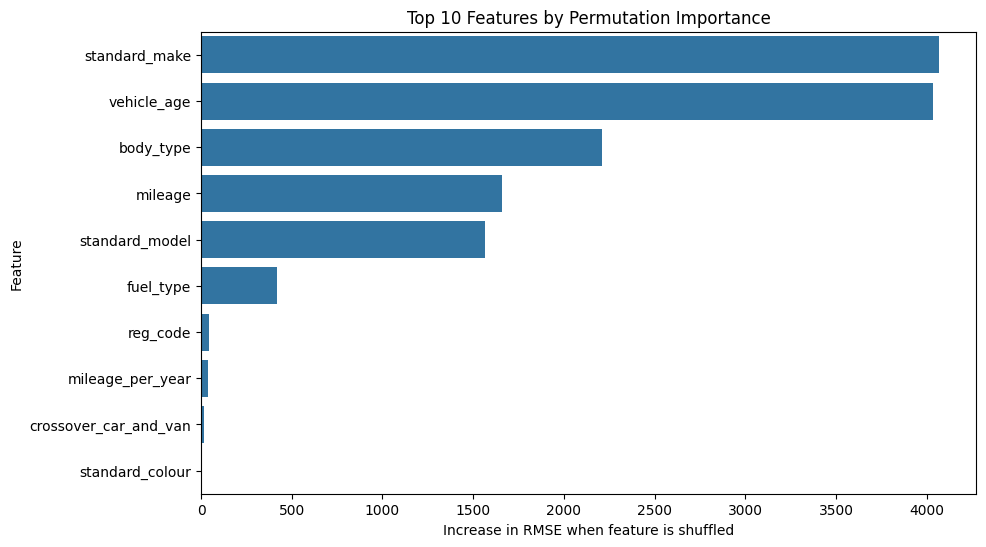

In [ ]:
# 34. Plot top permutation importance


# Selecting top 10
top_importance = importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_importance,
    x="Importance Mean",
    y="Feature"
)

plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.ylabel("Feature")
plt.show()

##Task 6: PDP  Model

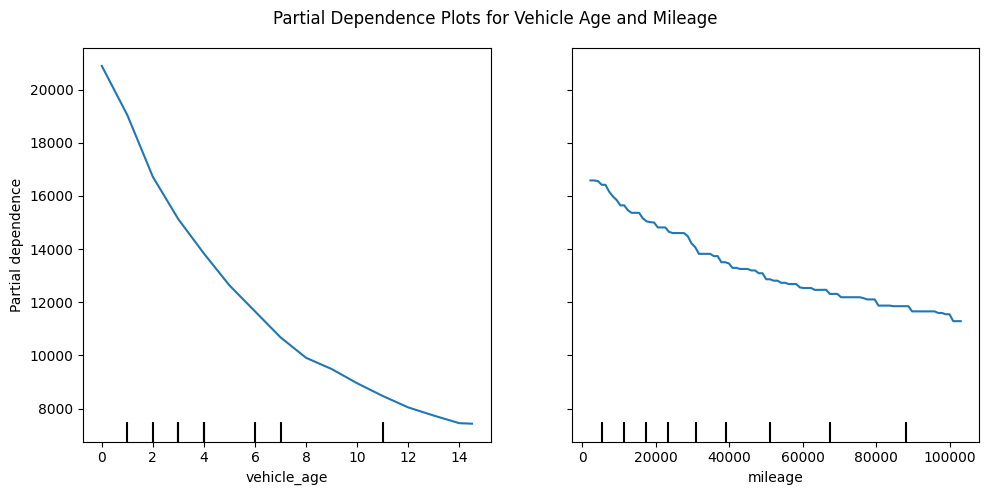

In [ ]:
#35. Partial Dependence for important features


#PDP shows the average effect
#2,000-row sample used .

X_test_pdp = X_test.sample(n=2000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

PartialDependenceDisplay.from_estimator(
    hgb_model,
    X_test_pdp,
    features=["vehicle_age", "mileage"],
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Vehicle Age and Mileage")
plt.tight_layout()
plt.show()

In [ ]:
#36. Install import SHAP


# SHAP used to explain how features contribute to model predictions
!pip install shap -q

import shap

In [ ]:
#37. Preparing sample data for SHAP


#small sample is used
X_train_shap = X_train.sample(n=20000, random_state=42)
y_train_shap = y_train.loc[X_train_shap.index]

X_test_shap = X_test.sample(n=500, random_state=42)
y_test_shap = y_test.loc[X_test_shap.index]

print("SHAP training sample:", X_train_shap.shape)
print("SHAP explanation sample:", X_test_shap.shape)

SHAP training sample: (20000, 11)
SHAP explanation sample: (500, 11)


In [ ]:
# 36.SHAP explanation

X_train_shap = X_train.sample(n=10000, random_state=42)
y_train_shap = y_train.loc[X_train_shap.index]

X_test_shap = X_test.sample(n=300, random_state=42)
y_test_shap = y_test.loc[X_test_shap.index]

print("SHAP training sample shape:", X_train_shap.shape)
print("SHAP test sample shape:", X_test_shap.shape)

SHAP training sample shape: (10000, 11)
SHAP test sample shape: (300, 11)


In [ ]:
#37. Preprocess SHAP
# Fitting preprocessor on sHAP training sample
preprocessor.fit(X_train_shap)

# Transforming SHAP training and test samples
X_train_shap_processed = preprocessor.transform(X_train_shap)
X_test_shap_processed = preprocessor.transform(X_test_shap)

# Convert sparse matrices to dense arrays
X_train_shap_dense = X_train_shap_processed.toarray()
X_test_shap_dense = X_test_shap_processed.toarray()

#feature names after one-hot encoding
shap_num_features = numerical_features

shap_cat_features = preprocessor.named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

shap_feature_names = np.concatenate([shap_num_features, shap_cat_features])

#Convert to DataFrames for readable names
X_train_shap_df = pd.DataFrame(X_train_shap_dense, columns=shap_feature_names)
X_test_shap_df = pd.DataFrame(X_test_shap_dense, columns=shap_feature_names)

print("Processed SHAP training shape:", X_train_shap_df.shape)
print("Processed SHAP test shape:", X_test_shap_df.shape)

Processed SHAP training shape: (10000, 739)
Processed SHAP test shape: (300, 739)


In [ ]:
# 38. Training Random Forest model for SHAP explanation


# A small Random Forest is trained
rf_shap_model = RandomForestRegressor(
    n_estimators=40,
    max_depth=14,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_shap_model.fit(X_train_shap_df, y_train_shap)

# Check SHAP performance on sample
rf_shap_pred = rf_shap_model.predict(X_test_shap_df)

print("SHAP Random Forest RMSE:", round(np.sqrt(mean_squared_error(y_test_shap, rf_shap_pred)), 2))
print("SHAP Random Forest R2:", round(r2_score(y_test_shap, rf_shap_pred), 4))

SHAP Random Forest RMSE: 3504.95
SHAP Random Forest R2: 0.8582


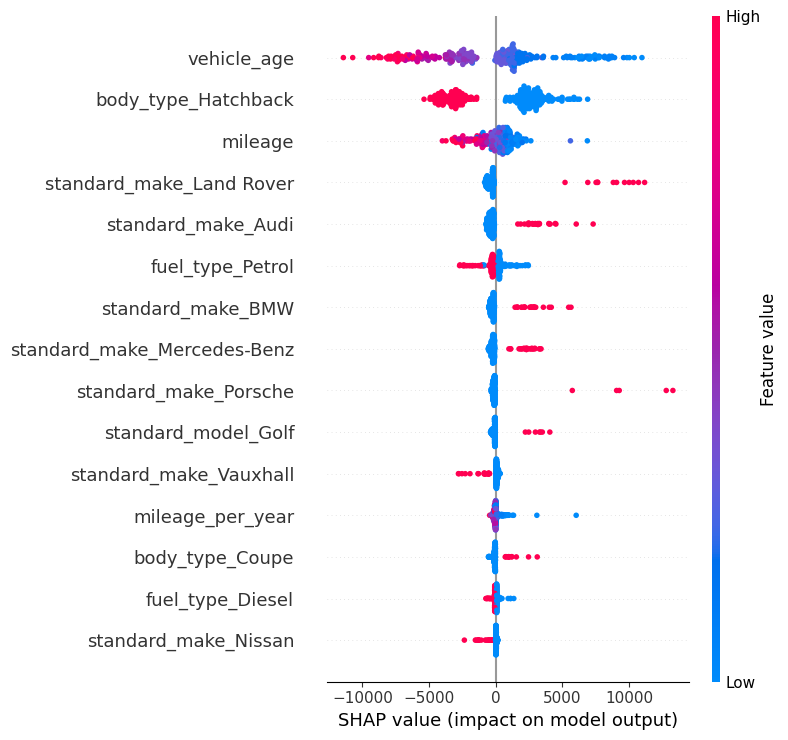

In [ ]:

#39 SHAP summary plot


#how each feature contributes
explainer = shap.TreeExplainer(rf_shap_model)

#avoids errors in TreeExplainer
shap_values = explainer.shap_values(
    X_test_shap_df,
    check_additivity=False
)

# Summary plot of influential features
shap.summary_plot(
    shap_values,
    X_test_shap_df,
    max_display=15
)

##Task 7: PCA Linear Dimensionality Reduction

In [ ]:
# 40. Preparing data for PCA


# PCA is heavy on full one-hot encoded dataset.
# 30,000-row training sample is used
X_train_pca_sample = X_train.sample(n=30000, random_state=42)
y_train_pca_sample = y_train.loc[X_train_pca_sample.index]

X_test_pca_sample = X_test.sample(n=10000, random_state=42)
y_test_pca_sample = y_test.loc[X_test_pca_sample.index]

print("PCA training sample shape:", X_train_pca_sample.shape)
print("PCA test sample shape:", X_test_pca_sample.shape)

PCA training sample shape: (30000, 11)
PCA test sample shape: (10000, 11)


In [ ]:
# 41. Preprocess PCA data


# PCA uses dense numeric input
# hgb_preprocessor already uses dense encoding.

hgb_preprocessor.fit(X_train_pca_sample)

X_train_pca_processed = hgb_preprocessor.transform(X_train_pca_sample)
X_test_pca_processed = hgb_preprocessor.transform(X_test_pca_sample)

print("Processed PCA training shape:", X_train_pca_processed.shape)
print("Processed PCA test shape:", X_test_pca_processed.shape)

Processed PCA training shape: (30000, 918)
Processed PCA test shape: (10000, 918)


In [ ]:
# 42. Linear dimensionality reduction using PCA


# PCA keeps enough components to explain 95% variance
pca = PCA(n_components=0.95, svd_solver="full", random_state=42)

X_train_pca = pca.fit_transform(X_train_pca_processed)
X_test_pca = pca.transform(X_test_pca_processed)

print("Original number of features:", X_train_pca_processed.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Original number of features: 918
Number of PCA components: 134
Total explained variance: 0.9501


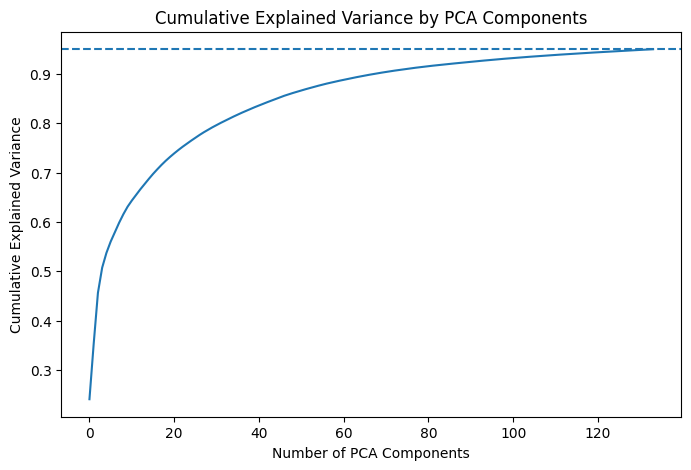

In [ ]:
# 43. Plot cumulative explained variance


# This plot shows speed of PCA captures dataset variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)
plt.axhline(y=0.95, linestyle="--")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [ ]:
# 44. Evaluate Ridge Regression using PCA features


# Ridge is used because it was the strongest linear baseline earlier
ridge_pca = Ridge(alpha=1.0)

# Train on PCA-reduced features
ridge_pca.fit(X_train_pca, y_train_pca_sample)

# Predict using PCA-reduced test data
ridge_pca_predictions = ridge_pca.predict(X_test_pca)

# Evaluate PCA model
mae_pca = mean_absolute_error(y_test_pca_sample, ridge_pca_predictions)
rmse_pca = np.sqrt(mean_squared_error(y_test_pca_sample, ridge_pca_predictions))
r2_pca = r2_score(y_test_pca_sample, ridge_pca_predictions)

model_results.append({
    "Model": "Ridge Regression + PCA",
    "MAE": mae_pca,
    "RMSE": rmse_pca,
    "R2": r2_pca
})

print("Ridge Regression + PCA")
print("MAE:", round(mae_pca, 2))
print("RMSE:", round(rmse_pca, 2))
print("R2:", round(r2_pca, 4))

Ridge Regression + PCA
MAE: 2948.6
RMSE: 4137.98
R2: 0.7927


In [ ]:
# 45. Comparing models after PCA


results_df = pd.DataFrame(model_results)

results_clean_df = results_df.sort_values("RMSE").drop_duplicates(
    subset=["Model"],
    keep="first"
)

results_clean_df = results_clean_df.sort_values(by="RMSE")

display(results_clean_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
8,Ridge Regression + PCA,2948.602787,4137.978142,0.792666
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535


##Task 8: Non-Linear dimensionality reduction using Isomap

In [ ]:
##46. Preparing sampled data for Isomap


# Isomap is computationally heavy, smaller sample used
# enough to demonstrate non-linear dimensionality reduction.

X_train_iso_sample = X_train.sample(n=5000, random_state=42)
y_train_iso_sample = y_train.loc[X_train_iso_sample.index]

X_test_iso_sample = X_test.sample(n=2000, random_state=42)
y_test_iso_sample = y_test.loc[X_test_iso_sample.index]

print("Isomap training sample shape:", X_train_iso_sample.shape)
print("Isomap test sample shape:", X_test_iso_sample.shape)

Isomap training sample shape: (5000, 11)
Isomap test sample shape: (2000, 11)


In [ ]:
# 47. Preprocess Isomap data


# Dense preprocessing used because Isomap need numeric array input
hgb_preprocessor.fit(X_train_iso_sample)

X_train_iso_processed = hgb_preprocessor.transform(X_train_iso_sample)
X_test_iso_processed = hgb_preprocessor.transform(X_test_iso_sample)

print("Processed Isomap training shape:", X_train_iso_processed.shape)
print("Processed Isomap test shape:", X_test_iso_processed.shape)

Processed Isomap training shape: (5000, 643)
Processed Isomap test shape: (2000, 643)


In [ ]:

# 48. Non-linear dimensionality reduction using Isomap


# Isomap reduce high-dimensional data to 2 components.
# preserves non-linear manifold structure using nearest-neighbour distances
isomap = Isomap(
    n_neighbors=10,
    n_components=2
)

X_train_isomap = isomap.fit_transform(X_train_iso_processed)
X_test_isomap = isomap.transform(X_test_iso_processed)

print("Isomap training shape:", X_train_isomap.shape)
print("Isomap test shape:", X_test_isomap.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Isomap training shape: (5000, 2)
Isomap test shape: (2000, 2)


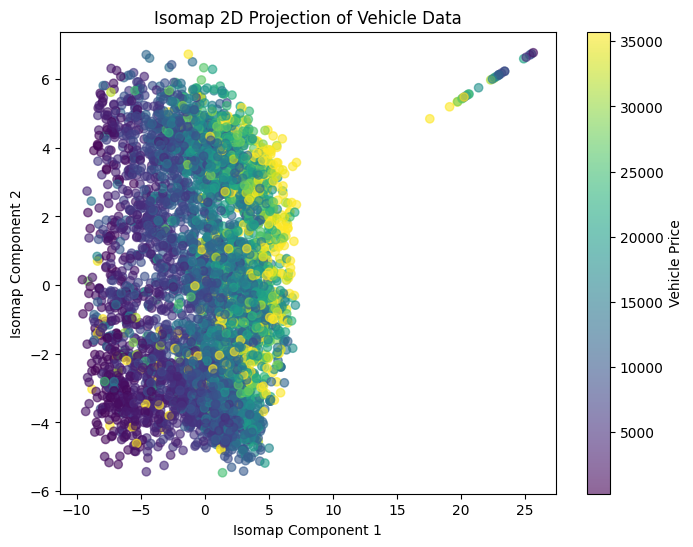

In [ ]:
# 49. Visualising Isomap components


# colour show vehicle price,whether reduced space separate price pattern
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_isomap[:, 0],
    X_train_isomap[:, 1],
    c=y_train_iso_sample,
    alpha=0.6
)

plt.colorbar(scatter, label="Vehicle Price")
plt.title("Isomap 2D Projection of Vehicle Data")
plt.xlabel("Isomap Component 1")
plt.ylabel("Isomap Component 2")
plt.show()

In [ ]:
# 50. Evaluating Ridge Regression using Isomap features


# Ridge Regression is trained on 2 Isomap components
ridge_isomap = Ridge(alpha=1.0)

ridge_isomap.fit(X_train_isomap, y_train_iso_sample)

isomap_predictions = ridge_isomap.predict(X_test_isomap)

mae_isomap = mean_absolute_error(y_test_iso_sample, isomap_predictions)
rmse_isomap = np.sqrt(mean_squared_error(y_test_iso_sample, isomap_predictions))
r2_isomap = r2_score(y_test_iso_sample, isomap_predictions)

model_results.append({
    "Model": "Ridge Regression + Isomap",
    "MAE": mae_isomap,
    "RMSE": rmse_isomap,
    "R2": r2_isomap
})

print("Ridge Regression + Isomap")
print("MAE:", round(mae_isomap, 2))
print("RMSE:", round(rmse_isomap, 2))
print("R2:", round(r2_isomap, 4))


Ridge Regression + Isomap
MAE: 4839.97
RMSE: 6772.64
R2: 0.4344


In [ ]:
# 51. Comparing models after Isomap

results_df = pd.DataFrame(model_results)

results_clean_df = results_df.sort_values("RMSE").drop_duplicates(
    subset=["Model"],
    keep="first"
)

results_clean_df = results_clean_df.sort_values(by="RMSE")

display(results_clean_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
8,Ridge Regression + PCA,2948.602787,4137.978142,0.792666
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535
9,Ridge Regression + Isomap,4839.967784,6772.636617,0.434432


##Task 9: Polynomial Regression


In [ ]:

# 52. Preparing selected features for polynomial regression


# Polynomial regression is too large if all features are included
# only key numerical features and low-cardinality categorical features used

df_poly = df_clean.copy()

# Converting reg_code to numeric because it has text value
df_poly["reg_code"] = pd.to_numeric(df_poly["reg_code"], errors="coerce")

# Filling invalid reg_code values with median instead of deleting rows
reg_code_median = df_poly["reg_code"].median()
df_poly["reg_code"] = df_poly["reg_code"].fillna(reg_code_median)

# Selected features for polynomial regression
poly_numeric_features = [
    "mileage",
    "vehicle_age",
    "mileage_per_year",
    "reg_code"
]

poly_categorical_features = [
    "vehicle_condition",
    "body_type",
    "fuel_type",
    "crossover_car_and_van"
]

poly_features = poly_numeric_features + poly_categorical_features

X_poly = df_poly[poly_features]
y_poly = df_poly["price"]

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y_poly,
    test_size=0.2,
    random_state=42
)

print("Polynomial numeric features:", poly_numeric_features)
print("Polynomial categorical features:", poly_categorical_features)
print("Training shape:", X_train_poly.shape)
print("Test shape:", X_test_poly.shape)

Polynomial numeric features: ['mileage', 'vehicle_age', 'mileage_per_year', 'reg_code']
Polynomial categorical features: ['vehicle_condition', 'body_type', 'fuel_type', 'crossover_car_and_van']
Training shape: (290739, 8)
Test shape: (72685, 8)


In [ ]:
# 53. Preprocessor for polynomial regression


# Numeric features are scaled
poly_numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Selected categorical features are one-hot encoded
poly_categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Applying correct preprocessing to numeric and categorical columns
poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly_numeric_transformer, poly_numeric_features),
        ("cat", poly_categorical_transformer, poly_categorical_features)
    ]
)

In [ ]:
# 54.Baseline Ridge Regression with selected features


# Ridge is used as linear baseline before polynomial
ridge_poly_baseline = Pipeline(steps=[
    ("preprocessor", poly_preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_poly_baseline.fit(X_train_poly, y_train_poly)

ridge_poly_baseline_predictions = ridge_poly_baseline.predict(X_test_poly)

mae_poly_base = mean_absolute_error(y_test_poly, ridge_poly_baseline_predictions)
rmse_poly_base = np.sqrt(mean_squared_error(y_test_poly, ridge_poly_baseline_predictions))
r2_poly_base = r2_score(y_test_poly, ridge_poly_baseline_predictions)

print("Ridge baseline with selected polynomial features")
print("MAE:", round(mae_poly_base, 2))
print("RMSE:", round(rmse_poly_base, 2))
print("R2:", round(r2_poly_base, 4))

Ridge baseline with selected polynomial features
MAE: 4530.97
RMSE: 6015.91
R2: 0.5653


In [ ]:
# 55. Polynomial Regression with selected categorical features


# PolynomialFeatures create squared terms.
# Degree 2 is to control complexity.
poly_regression_model = Pipeline(steps=[
    ("preprocessor", poly_preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

poly_regression_model.fit(X_train_poly, y_train_poly)

poly_predictions = poly_regression_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test_poly, poly_predictions)
rmse_poly = np.sqrt(mean_squared_error(y_test_poly, poly_predictions))
r2_poly = r2_score(y_test_poly, poly_predictions)

print("Polynomial Regression with selected categorical features")
print("MAE:", round(mae_poly, 2))
print("RMSE:", round(rmse_poly, 2))
print("R2:", round(r2_poly, 4))

Polynomial Regression with selected categorical features
MAE: 3893.76
RMSE: 5436.4
R2: 0.645


In [ ]:
# 56. Comparing baseline and polynomial regression


poly_comparison_df = pd.DataFrame({
    "Model": [
        "Ridge Baseline Selected Features",
        "Polynomial Regression Selected Features"
    ],
    "MAE": [mae_poly_base, mae_poly],
    "RMSE": [rmse_poly_base, rmse_poly],
    "R2": [r2_poly_base, r2_poly]
})

poly_comparison_df = poly_comparison_df.sort_values(by="RMSE")

display(poly_comparison_df)

,Model,MAE,RMSE,R2
1,Polynomial Regression Selected Features,3893.763038,5436.39931,0.645002
0,Ridge Baseline Selected Features,4530.966438,6015.91058,0.565284


In [ ]:
# 57. Adding polynomial result to results table

model_results.append({
    "Model": "Polynomial Regression Selected Features",
    "MAE": mae_poly,
    "RMSE": rmse_poly,
    "R2": r2_poly
})

results_df = pd.DataFrame(model_results)

results_clean_df = results_df.sort_values("RMSE").drop_duplicates(
    subset=["Model"],
    keep="first"
)

results_clean_df = results_clean_df.sort_values(by="RMSE")

display(results_clean_df)

,Model,MAE,RMSE,R2
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
8,Ridge Regression + PCA,2948.602787,4137.978142,0.792666
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535
10,Polynomial Regression Selected Features,3893.763038,5436.399310,0.645002
9,Ridge Regression + Isomap,4839.967784,6772.636617,0.434432


##Task 10: Clustering for feature engineering

In [ ]:
# 57. Preparing data for clustering feature engineering


# Clustering creates a new feature that keeps similar vehicles grouped
# K-Means is distance based,only numerical features are used

df_cluster = df_poly.copy()

cluster_features = [
    "mileage",
    "vehicle_age",
    "mileage_per_year",
    "reg_code"
]

X_cluster = df_cluster[cluster_features].copy()

print("Clustering features:")
print(cluster_features)

print("\nClustering data shape:", X_cluster.shape)
print("\nData types:")
print(X_cluster.dtypes)

Clustering features:
['mileage', 'vehicle_age', 'mileage_per_year', 'reg_code']

Clustering data shape: (363424, 4)

Data types:
mileage             float64
vehicle_age         float64
mileage_per_year    float64
reg_code            float64
dtype: object


In [ ]:
# 58. Scale clustering features


# K-Means use distance,scaling is needed.
# preventing big features like mileage from dominating smaller eatures.

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Scaled clustering data shape:", X_cluster_scaled.shape)

Scaled clustering data shape: (363424, 4)


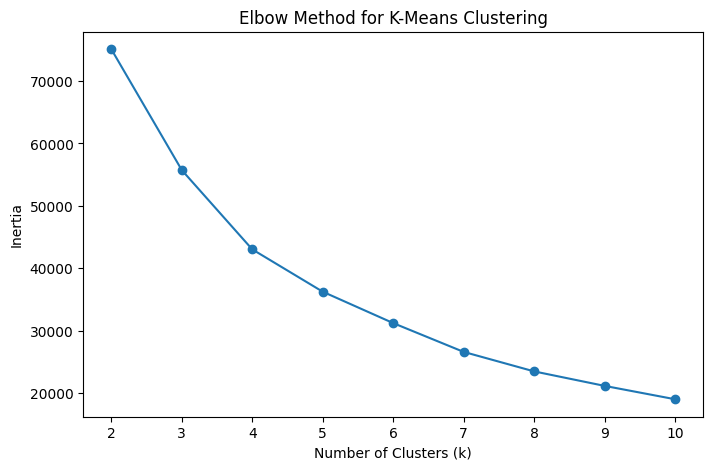

In [ ]:
# 59. Elbow method to choose number of clusters


# 30,000 sample used to make elbow method faster.
X_cluster_sample = pd.DataFrame(X_cluster_scaled).sample(n=30000, random_state=42)

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_sample)
    inertia_values.append(kmeans.inertia_)

# Plotting  elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

,k,Silhouette Score
0,2,0.350501
1,3,0.368690
2,4,0.385062
3,5,0.381740
4,6,0.398018
5,7,0.368409
6,8,0.365071
7,9,0.369228
8,10,0.369789


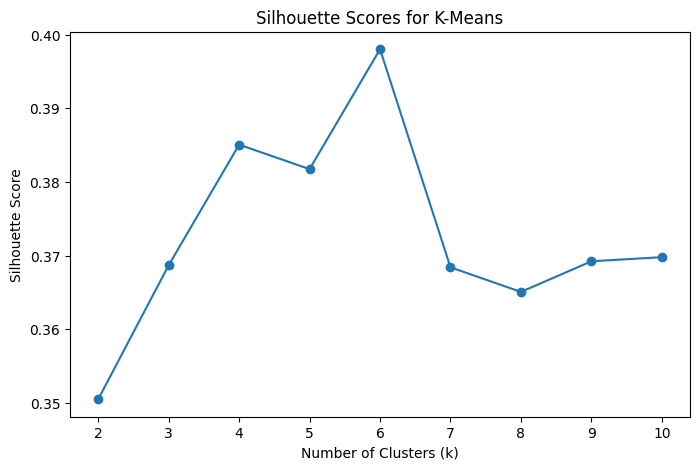

In [ ]:
# 60. Silhouette score for cluster evaluation


# Silhouette score measures how separated the clusters are
# Higher score means better clustering

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_sample)
    score = silhouette_score(X_cluster_sample, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

##FINAL K

In [ ]:
#61. Fitting final K-Means model


# k=6 is selected because highest silhouette score
final_k = 6

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

# Creatinng cluster labels for the whole dataset
df_clustered = df_poly.copy()
df_clustered["vehicle_cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

print("Cluster counts:")
print(df_clustered["vehicle_cluster"].value_counts().sort_index())

Cluster counts:
vehicle_cluster
0     65649
1     42349
2    106263
3     37616
4     40342
5     71205
Name: count, dtype: int64


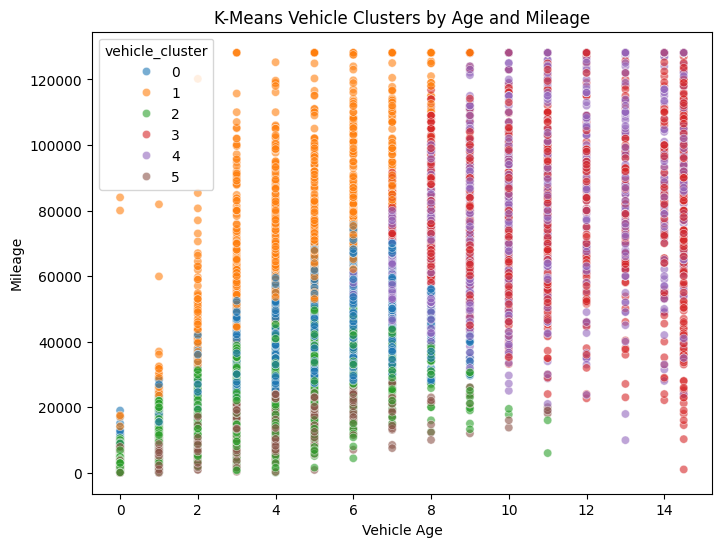

In [ ]:
# 62. Visualising vehicle clusters

# This plot shows how clusters relate to vehicle age and mileage.
# A sample is used to keep plot readable.

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clustered.sample(n=10000, random_state=42),
    x="vehicle_age",
    y="mileage",
    hue="vehicle_cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("K-Means Vehicle Clusters by Age and Mileage")
plt.xlabel("Vehicle Age")
plt.ylabel("Mileage")
plt.show()

In [ ]:
#63. Creating dataset with cluster feature


# The cluster label is a new feature for prediction.
X_cluster_model = df_clustered.drop(columns=["price", "public_reference", "year_of_registration"])
y_cluster_model = df_clustered["price"]

# vehicle_cluster is a category label not numeric value
X_cluster_model["vehicle_cluster"] = X_cluster_model["vehicle_cluster"].astype("object")

# Identifying numerical and categorical columns
cluster_numerical_features = X_cluster_model.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

cluster_categorical_features = X_cluster_model.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(cluster_numerical_features)

print("\nCategorical features:")
print(cluster_categorical_features)

Numerical features:
['mileage', 'reg_code', 'crossover_car_and_van', 'vehicle_age', 'mileage_per_year']

Categorical features:
['standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type', 'vehicle_cluster']


In [ ]:
#64. Split clustered dataset


X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = train_test_split(
    X_cluster_model,
    y_cluster_model,
    test_size=0.2,
    random_state=42
)

print("Cluster model training shape:", X_train_cluster.shape)
print("Cluster model test shape:", X_test_cluster.shape)

Cluster model training shape: (290739, 12)
Cluster model test shape: (72685, 12)


In [ ]:
# 65. Preprocessor for clustered model


# Numeric features scaled
cluster_numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical features are one-hot encoded as output for HistGradientBoosting
cluster_categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", cluster_numeric_transformer, cluster_numerical_features),
        ("cat", cluster_categorical_transformer, cluster_categorical_features)
    ]
)

In [ ]:
# 66. Evaluating HistGradientBoosting with K-Means cluster feature


# HistGradientBoosting is used because its the best model earlier.
# The new vehicle_cluster feature is test if clustering improves prediction.

hgb_cluster_model = Pipeline(steps=[
    ("preprocessor", cluster_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ))
])

hgb_cluster_model.fit(X_train_cluster, y_train_cluster)

cluster_predictions = hgb_cluster_model.predict(X_test_cluster)

mae_cluster = mean_absolute_error(y_test_cluster, cluster_predictions)
rmse_cluster = np.sqrt(mean_squared_error(y_test_cluster, cluster_predictions))
r2_cluster = r2_score(y_test_cluster, cluster_predictions)

model_results.append({
    "Model": "HistGradientBoosting + KMeans Cluster",
    "MAE": mae_cluster,
    "RMSE": rmse_cluster,
    "R2": r2_cluster
})

print("HistGradientBoosting + KMeans Cluster")
print("MAE:", round(mae_cluster, 2))
print("RMSE:", round(rmse_cluster, 2))
print("R2:", round(r2_cluster, 4))

HistGradientBoosting + KMeans Cluster
MAE: 1640.5
RMSE: 2408.62
R2: 0.9303


In [ ]:
# 67.Final model comparison table


results_df = pd.DataFrame(model_results)

# Keeps best result for each model
results_clean_df = results_df.sort_values("RMSE").drop_duplicates(
    subset=["Model"],
    keep="first"
)

results_clean_df = results_clean_df.sort_values(by="RMSE")

display(results_clean_df)

,Model,MAE,RMSE,R2
11,HistGradientBoosting + KMeans Cluster,1640.502872,2408.615044,0.930315
5,HistGradientBoosting,1645.832890,2415.406038,0.929922
3,Ridge Regression,2071.550789,2848.742127,0.902521
2,Linear Regression,2070.145728,2849.929308,0.902440
1,Random Forest,1959.680135,2942.613853,0.895991
7,Voting Regressor Sampled,2095.908441,3087.014239,0.885533
6,Extra Trees Sampled,2299.011533,3355.824229,0.864730
8,Ridge Regression + PCA,2948.602787,4137.978142,0.792666
4,Ridge Regression + Feature Selection,3627.806452,4727.617983,0.731535
10,Polynomial Regression Selected Features,3893.763038,5436.399310,0.645002


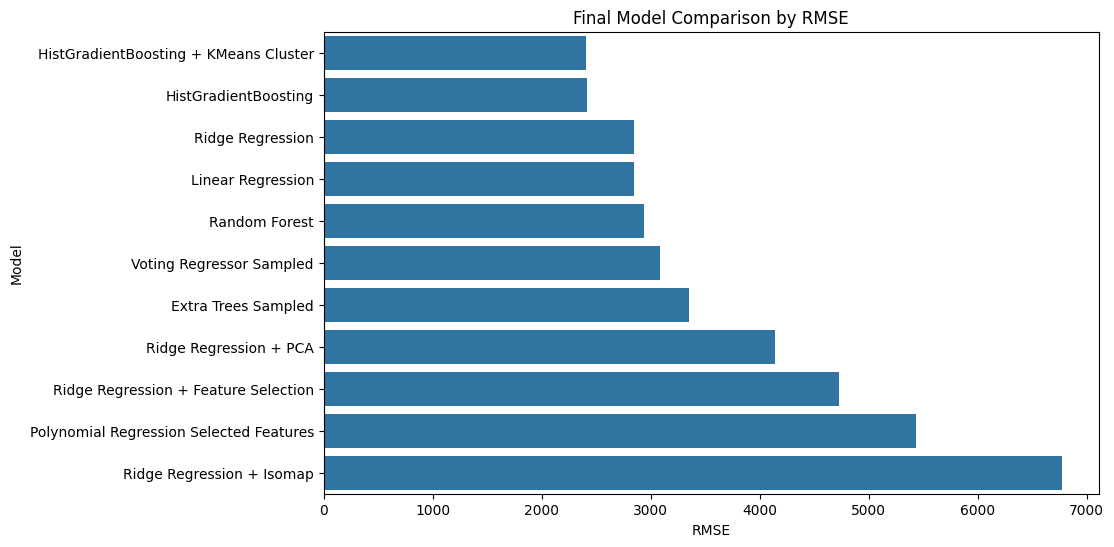

In [ ]:
# 68. Final RMSE comparison graph


#graph compares the RMSE of each model.
#Lower RMSE = better prediction accuracy.

# Sort models by RMSE
rmse_plot_df = results_clean_df.sort_values(by="RMSE")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rmse_plot_df,
    x="RMSE",
    y="Model"
)

plt.title("Final Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()